# Sun Baseline and Delay Determination

This notebook estimates geometric delay and baseline from Sun fringes measured by a two-element interferometer. The derivation below starts from the electric field at two antennas, builds the geometric-delay and fringe equations, then generalizes from a point source to an extended source. The endpoint is the uniform-disk visibility of the Sun, whose Fourier transform produces the Bessel-function response used to interpret when the source becomes resolved.

## 1. What an interferometer measures

A single antenna measures a voltage proportional to the incident electric field. Two antennas observing the same monochromatic plane wave see nearly the same waveform, but shifted in time because the wave reaches one antenna before the other.

Let the baseline vector from antenna 1 to antenna 2 be $\mathbf{b}$, and let $\hat{s}$ be a unit vector pointing toward the source on the sky. For a monochromatic field of angular frequency $\omega = 2\pi \nu$,

$$E(\mathbf{r}, t) = E_0 e^{i(\omega t - \mathbf{k} \cdot \mathbf{r})}, \qquad |\mathbf{k}| = \frac{2\pi}{\lambda}.$$

If antenna 1 is at $\mathbf{r}_1$ and antenna 2 is at $\mathbf{r}_2 = \mathbf{r}_1 + \mathbf{b}$, then the phase difference is

$$\Delta \phi = \mathbf{k} \cdot \mathbf{b} = \frac{2\pi}{\lambda} \, \mathbf{b} \cdot \hat{s}.$$

Equivalently, the same phase difference can be written as a time delay,

$$\tau_g = \frac{\mathbf{b} \cdot \hat{s}}{c},$$

called the **geometric delay**. It is the extra propagation time required for the wavefront to travel from one antenna to the other.

The correlator forms a time average of the product of the two antenna voltages. In complex notation,

$$V_{12} \equiv \langle v_1(t) v_2^*(t) \rangle.$$

For a perfect point source with flux density $S_\nu$, this is proportional to

$$V_{12} \propto S_\nu \, e^{-i 2\pi \nu \tau_g},$$

up to an overall complex gain and instrumental phase. The two basic observables are therefore:

- the **visibility amplitude** $|V_{12}|$, which says how coherent the source appears on that baseline;
- the **visibility phase** $\arg V_{12}$, which tracks the differential delay.

For an unresolved point source the visibility amplitude stays large. For an extended source, different parts of the source contribute with different phases and partially cancel.

## 2. Geometric delay, phase, and Earth-rotation fringes

### Source direction in hour angle and declination

For an equatorial source with declination $\delta$ and hour angle $h$, the sky direction written in local east-north-up coordinates is

$$\hat{s} = \begin{bmatrix}
\cos \delta \sin h \\
\sin \phi \cos \delta \cos h - \cos \phi \sin \delta \\
\cos \phi \cos \delta \cos h + \sin \phi \sin \delta
\end{bmatrix},$$

where $\phi$ is the observatory latitude. The geometric delay is always the dot product of this direction with the physical baseline vector.

### Point-source fringe phase

For a general baseline $\mathbf{b}$,

$$\tau_g(h, \delta) = \frac{\mathbf{b} \cdot \hat{s}}{c}, \qquad \varphi = -2\pi \nu \tau_g + \varphi_0,$$

where $\varphi_0$ collects instrumental cable delays, correlator phase offsets, and any phase-center convention. As Earth rotates, the hour angle changes according to

$$h(t) = \mathrm{LST}(t) - \alpha,$$

so the projected baseline seen by the source changes continuously even though the hardware is fixed. The correlator output therefore oscillates in time: these oscillations are the **interferometric fringes**.

Physically, a fringe is produced whenever Earth rotation causes the geometric path difference to change by one wavelength. Each additional wavelength of path difference advances the complex phase by $2\pi$ and completes one fringe cycle.

### Specialization to a pure east-west baseline

For this lab the useful baseline component is the east-west component $B_\mathrm{EW}$. If

$$\mathbf{b} = B_\mathrm{EW} \, \hat{e}_E,$$

then only the east component of $\hat{s}$ matters, so

$$\tau_g = \frac{B_\mathrm{EW}}{c} \cos \delta \sin h.$$

With the sign convention used in the notebook,

$$\Delta l = \mathbf{b} \cdot \hat{s} = -B_\mathrm{EW} \cos \delta \sin h,$$

and therefore

$$\boxed{\varphi(h) = -\frac{2\pi \nu}{c} B_\mathrm{EW} \cos \delta \sin h + \varphi_0.}$$

The important geometry is that an east-pointing unit vector is perpendicular to the polar axis, so the declination dependence remains, but the explicit latitude dependence drops out after projecting onto the east direction. Near transit, $|\cos h|$ is largest, so the phase changes fastest there and the fringes are most rapid.

## 3. Fringe rate, delay extraction, and baseline recovery

### Fringe frequency from the phase model

Differentiate the phase with respect to hour angle:

$$\frac{d\varphi}{dh} = -\frac{2\pi \nu}{c} B_\mathrm{EW} \cos \delta \cos h.$$

Divide by $2\pi$ to convert phase slope into cycles per radian of hour angle, then multiply by $\pi/180$ to express the result in cycles per degree:

$$\boxed{f_\mathrm{fringe}\,[\mathrm{cyc\,deg^{-1}}] = \frac{\nu}{c} B_\mathrm{EW} \cos \delta \, |\cos h| \frac{\pi}{180}.}$$

This has the expected behavior:

- it is largest at transit, where $h = 0$ and the source moves fastest in the east-west direction;
- it goes to zero near $h = \pm 90^\circ$, where the east component of the source direction stops changing.

Solving for the east-west baseline gives

$$\boxed{B_\mathrm{EW} = \frac{f_\mathrm{fringe} \, c}{\nu \cos \delta \, |\cos \bar{h}| \, (\pi/180)}.}$$

This is the working conversion from measured fringe rate to projected baseline used later in the notebook.

### Delay as a path-length or correlator observable

The same geometry can be discussed in either path-length or time-delay language:

$$\Delta l = \mathbf{b} \cdot \hat{s}, \qquad \tau_g = \frac{\Delta l}{c}.$$

A broadband correlator is sensitive not only to phase at one channel, but also to the relative lag at which the two signals line up best. If the cross-spectrum is $V(\nu)$, then its Fourier transform with respect to frequency gives a lag-domain response,

$$R(\tau) = \int V(\nu) e^{i 2\pi \nu \tau} \, d\nu.$$

A peak in $R(\tau)$ occurs near the residual delay between the two signal paths. In practice:

- **phase slope versus time** is used to infer fringe rate and hence baseline;
- **phase slope versus frequency** or a **lag-spectrum peak** is used to infer delay.

The phase and lag views are two faces of the same physics: both measure how much additional propagation time the baseline introduces.

## 4. Extended sources and the van Cittert-Zernike theorem

A real astronomical source is not a point. Different directions on the sky contribute different geometric delays, so the total visibility is a superposition over the source brightness distribution $I(\hat{s})$:

$$V(\mathbf{b}) = \int I(\hat{s}) \, e^{-i 2\pi \nu \tau_g(\hat{s})} \, d\Omega.$$

In the small-field, quasi-monochromatic limit, introduce direction cosines $(l,m)$ relative to the phase center and baseline coordinates in wavelengths,

$$u = \frac{b_x}{\lambda}, \qquad v = \frac{b_y}{\lambda}.$$

Then the visibility becomes

$$V(u,v) = \iint I(l,m) \, e^{-i 2\pi (ul + vm)} \, dl \, dm.$$

This is the **van Cittert-Zernike theorem**: the mutual coherence measured by the interferometer is the Fourier transform of the sky brightness distribution.

Its physical meaning is central:

- short baselines sample low spatial frequencies and are sensitive to broad structure;
- long baselines sample high spatial frequencies and resolve fine angular detail;
- the visibility amplitude decreases as the source becomes resolved on that baseline.

For a circularly symmetric source, the visibility depends only on the radial spatial frequency

$$\rho = \sqrt{u^2 + v^2} = \frac{B_\mathrm{proj}}{\lambda},$$

where $B_\mathrm{proj}$ is the projected baseline length perpendicular to the line of sight. Earth rotation moves the instrument through different projected baselines, so even a fixed physical baseline traces different points in Fourier space as the source drifts.

## 5. Uniform solar disk: why Bessel functions appear

Model the Sun as a uniform circular disk of angular radius $\alpha$ and constant brightness $I_0$ inside the disk, zero outside. Because the source is circularly symmetric, it is best to evaluate the visibility in polar coordinates on the sky.

Let the radial angle from the disk center be $\theta$ and let the polar angle be $\psi$. Then

$$V(\rho) = I_0 \int_0^{2\pi} \int_0^{\alpha} e^{-i 2\pi \rho \theta \cos \psi} \, \theta \, d\theta \, d\psi.$$

The angular integral is the standard Bessel identity

$$\int_0^{2\pi} e^{-i x \cos \psi} d\psi = 2\pi J_0(x),$$

so the visibility reduces to

$$V(\rho) = 2\pi I_0 \int_0^{\alpha} \theta J_0(2\pi \rho \theta) \, d\theta.$$

Using

$$\int_0^{a} r J_0(kr) \, dr = \frac{a J_1(ka)}{k},$$

we obtain

$$V(\rho) = 2\pi I_0 \frac{\alpha J_1(2\pi \rho \alpha)}{2\pi \rho}.$$

Normalize by the zero-baseline flux $V(0) = I_0 \pi \alpha^2$ to get the dimensionless visibility,

$$\boxed{\mathcal{V}(\rho) = \frac{2 J_1(2\pi \rho \alpha)}{2\pi \rho \alpha}.}$$

Writing the angular diameter as $\theta_d = 2\alpha$ and using $\rho = B_\mathrm{proj}/\lambda$ gives the standard uniform-disk result

$$\boxed{\mathcal{V}(B_\mathrm{proj}) = \frac{2 J_1(x)}{x}, \qquad x = \pi \theta_d \frac{B_\mathrm{proj}}{\lambda}.}$$

This formula explains the behavior of the Sun on longer baselines:

- when $x \ll 1$, $J_1(x) \approx x/2$, so $\mathcal{V} \approx 1$ and the Sun is effectively unresolved;
- as $x$ grows, different parts of the solar disk interfere destructively and the visibility amplitude falls;
- the first null occurs when $x \approx 3.8317$, the first zero of $J_1$.

Hence the first baseline that fully resolves a uniform disk is approximately

$$B_\mathrm{null} \approx \frac{3.8317}{\pi} \frac{\lambda}{\theta_d} \approx 1.22 \frac{\lambda}{\theta_d}.$$

For the Sun, whose angular diameter is roughly half a degree, this gives the characteristic baseline scale at which the measured correlated amplitude begins to collapse. That drop is not a loss of total power from the Sun; it is a loss of **coherence** on the chosen baseline.

## 6. Connection to the notebook observables

The code below uses this chain of ideas directly:

- `ha_deg` computes the source hour angle $h(t)$, which drives the projected delay and the fringe pattern;
- the complex correlator output `corr` or DC-corrected `corr_dc_chips` is the measured visibility $V_{12}$ in each spectral channel;
- the phase evolution of a channel measures $-2\pi \nu \tau_g$ plus instrumental offsets;
- the lag-domain summary estimates residual delay by locating the correlation peak in lag space;
- a fitted fringe rate converts to an east-west baseline through the $B_\mathrm{EW}$ formula above;
- amplitude loss versus projected baseline can be interpreted with the uniform-disk visibility law $2J_1(x)/x$.

So the full logic of the experiment is:

1. Earth rotation changes the projected geometric delay.
2. That changing delay produces fringes in the complex correlator output.
3. The fringe rate reveals the projected baseline.
4. The lag-domain peak reveals the delay.
5. The amplitude as a function of projected baseline reveals whether the Sun is resolved, with the uniform-disk model predicting a Bessel-function visibility.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import get_sun
from astropy.time import Time
from ugradiolab import NCH_LON_DEG

from utils.constants import (
    F_S_HZ,
    N_FFT,
    LO1_HZ,
    LO2_HZ,
    IF1_BPF_CENTER_HZ,
    IF1_BPF_HALF_BW_HZ,
    PLOT_BAND_GHZ,
    F_RF0_HZ,
)

from utils.captures import load_capture_series
from utils.chips import segment_capture_times_by_gap
from utils.dc import local_real_dc_correction
from utils.plotter import (
    plot_baseline_vs_frequency,
    plot_fft_peak_diagnostic,
    plot_fringe_rate_vs_frequency,
    plot_interval_baseline,
    plot_lag_delay_summary,
)


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data/lab03/sun_calibration')

paths = sorted(DATA_DIR.glob('*.npz'))
captures = load_capture_series(paths)

N_CH = captures.N_CH
DF_HZ = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {captures.N_cap} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')
print(f'Analysis band : {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

all_amp = np.abs(captures.corr).astype(float)
all_amp[:, BAD_CHANNELS] = np.nan

print(f'Masked : {BAD_CHANNELS}  '
      f'({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# ── Normalise ─────────────────────────────────────────────────────────────
AMP_PEAK = np.nanmax(all_amp)
print(f'Peak   : {AMP_PEAK:.4g}')


Loaded 8257 captures  |  10.2900 -- 10.5398 GHz  |  244.1 kHz/ch
Analysis band : 10.415 -- 10.485 GHz
Masked : [0, 256, 512, 768]  (['10.2900 GHz', '10.3525 GHz', '10.4150 GHz', '10.4775 GHz'])
Peak   : 2.131


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    return get_sun(Time(unix_t, format='unix')).ra.deg

order = np.argsort(captures.unix_mid)
captures_s = captures.take(order)
unix_sort = captures_s.unix_mid
N_cap = captures_s.N_cap

lst_arr     = np.array([_lst_deg(t)    for t in unix_sort])
sun_ra_arr  = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg      = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

chip_info = segment_capture_times_by_gap(
    unix_time_start_sorted=captures_s.unix_time_start,
    unix_time_end_sorted=captures_s.unix_time_end,
    unix_sorted=unix_sort,
    ha_deg=ha_deg,
)
chip_slices = chip_info.chip_slices
corr_chips = [captures_s.corr[s] for s in chip_slices]
unix_chips = chip_info.unix_chips
ha_chips = chip_info.ha_chips
N_caps = chip_info.N_caps
cap_chip = chip_info.cap_chip
_gaps = chip_info.gap_s

print(f'Chip split threshold: {chip_info.split_gap_threshold_sec:.3f} s')
if chip_info.gap_break_indices.size:
    for break_idx, gap_s in zip(chip_info.gap_break_indices, chip_info.gap_break_values_sec):
        print(f'Break at index {break_idx-1}→{break_idx}: {gap_s:.1f} s  ({gap_s/60:.1f} min)')
else:
    print('No chip breaks detected.')

for chip_idx, (n_cap_chip, ha_chip) in enumerate(zip(N_caps, ha_chips)):
    print(f'Chip {chip_idx}: {n_cap_chip} captures,  HA {ha_chip.min():.2f}° → {ha_chip.max():.2f}°')

# Peak channel within PLOT_BAND_GHZ (excluding artifact channels)
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak = captures_s.corr[:, k_peak]

print()
print(f'Sun RA   : {sun_ra_arr.min():.4f} -- {sun_ra_arr.max():.4f} deg  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f} deg)')
print(f'HA range : {ha_deg.min():.2f}° -> {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')


Chip split threshold: 5.000 s
Break at index 5538→5539: 153.8 s  (2.6 min)
Break at index 5941→5942: 133.8 s  (2.2 min)
Break at index 8250→8251: 1001.0 s  (16.7 min)
Chip 0: 5539 captures,  HA -80.78° → -8.43°
Chip 1: 403 captures,  HA -7.78° → -3.50°
Chip 2: 2309 captures,  HA -2.94° → 22.03°
Chip 3: 6 captures,  HA 26.21° → 26.27°

Sun RA   : 359.6663 -- 359.9374 deg  (span 0.2711 deg)
HA range : -80.78° -> 26.27°  (107.05° span)
Peak channel : k=579,  f_sky=10.4314 GHz


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_7835/3965795349.py:54: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


In [4]:
# ---------------------------------------------------------------------------
# Local DC correction per chip — rolling real-median pedestal subtraction.
# Each chip is corrected independently, and the local window never crosses
# chip boundaries.
# corr_chips[c]    : (N_caps[c], N_CH)  raw complex visibility
# corr_dc_chips[c] : (N_caps[c], N_CH)  locally DC-corrected complex visibility
# corr_dc          : (N_cap, N_CH)      full sequence (for non-gap-sensitive cells)
# ---------------------------------------------------------------------------

NOMINAL_FRINGE_PERIOD_SEC = 40.0
LOCAL_DC_PERIODS = 2.5
LOCAL_DC_WINDOW_SEC = NOMINAL_FRINGE_PERIOD_SEC * LOCAL_DC_PERIODS

dc_result = local_real_dc_correction(
    corr_chips=corr_chips,
    unix_chips=unix_chips,
    bad_channels=BAD_CHANNELS,
    nominal_fringe_period_sec=NOMINAL_FRINGE_PERIOD_SEC,
    window_periods=LOCAL_DC_PERIODS,
)

corr_dc_chips = dc_result.corr_dc_chips
corr_dc = dc_result.corr_dc
real_dc_offset_chips = dc_result.real_offset_chips

print(f'Local DC target window: {dc_result.window_sec:.1f} s')
for chip_idx, (cadence_sec, window_caps) in enumerate(
    zip(dc_result.median_cadence_sec_chips, dc_result.window_caps_chips)
):
    cadence_label = f'{cadence_sec:.2f} s' if np.isfinite(cadence_sec) else 'single capture'
    print(f'Chip {chip_idx}: median cadence {cadence_label},  local window {window_caps} captures')


Local DC target window: 100.0 s
Chip 0: median cadence 2.66 s,  local window 39 captures
Chip 1: median cadence 2.51 s,  local window 41 captures
Chip 2: median cadence 2.51 s,  local window 41 captures
Chip 3: median cadence 2.54 s,  local window 6 captures


## FFT baseline method: physical picture, normalization, and derivation

For a point source observed with an east-west baseline, the complex visibility in one spectral channel obeys

$$V_k(h) \approx A_k\,\exp\!\left[-i\,\frac{2\pi \nu_k}{c}\,B_{\rm EW}\cos\delta\,\sin h + i\phi_{0,k}\right],$$

where $A_k$ is the complex source-plus-gain amplitude and $\phi_{0,k}$ is an instrumental phase offset. The key point is that the phase is **not linear in hour angle**. It is linear in $\sin h$. Therefore a direct FFT of $V_k$ versus $h$ is not a pure single-frequency transform: the signal is chirped in $h$, so the power spreads over multiple Fourier bins instead of concentrating at one peak.

To remove that known geometric chirp, define the dimensionless coordinate

$$x \equiv \cos\delta\,\sin h.$$

This is the normalization used in the cell below. It absorbs the day-dependent factor that makes the apparent fringe rate speed up and slow down during the scan. In terms of $x$,

$$V_k(x) \approx A_k\,\exp\!\left[-i\,2\pi f_{x,k} x + i\phi_{0,k}\right],$$

with

$$f_{x,k} = \frac{\nu_k B_{\rm EW}}{c}.$$

Now the visibility is approximately a single complex sinusoid in $x$, so the FFT peak is sharply localized. Once the peak frequency $f_{x,k}$ is found, the baseline follows immediately from

$$\boxed{B_{\rm EW} = \frac{|f_{x,k}|\,c}{\nu_k}.}$$

So this method does **not** measure a raw time fringe rate. It first divides out the known sky-geometry dependence, then measures the residual spatial fringe frequency that depends only on baseline and observing frequency.

### Why the preprocessing looks the way it does

The FFT implementation adds a few numerical steps that are not extra physics, but are needed to make the estimator behave well:

- **Sort and interpolate onto a uniform $x$ grid:** the FFT assumes uniform sample spacing in the transform variable. The captures are nearly uniform in time, but not exactly uniform in $x$.
- **Subtract the complex mean:** any residual DC visibility or slowly varying pedestal produces a strong zero-frequency spike. Since we want the oscillatory fringe term, removing the mean suppresses that contamination.
- **Apply a Hann window:** each chip is a finite observation, so truncation would otherwise leak power into neighboring bins. The window reduces spectral leakage and makes the peak cleaner.
- **Zero-pad before the FFT:** this does not increase the true resolution set by the chip span in $x$, but it does interpolate the discrete spectrum and improves peak localization.
- **Use off-peak power for an FFT SNR:** the ratio of the main peak to the off-peak median is a practical way to summarize how dominant the recovered fringe tone is.

### What is and is not normalized

There is no amplitude normalization to unit visibility in this method, because the baseline comes from the **location** of the FFT peak, not from its amplitude. Source brightness, gain variations, and partial resolution of the Sun can change the peak height, but to first order they do not move the peak frequency. The only essential normalization is the coordinate change from $(h,\delta)$ to the dimensionless variable $x = \cos\delta\,\sin h$.

### How the uncertainty is estimated

The FFT peak is not infinitely sharp, even for a perfect tone, because each chip covers only a finite range in

$$\Delta x = x_{\max} - x_{\min}.$$ 

Observing a sinusoid only over a finite interval multiplies the true signal by a window $W(x)$. In Fourier space, that means the ideal delta-function peak is convolved with the transform of the window, so the peak acquires a finite width. The natural frequency-resolution scale is therefore set by the inverse span,

$$\Delta f_{x,\rm span} \sim \frac{1}{\Delta x}.$$ 

Because the code below uses a Hann window and does not fit a full likelihood model for the peak shape, it adopts a practical span-limited floor

$$\sigma_{f_x,\rm span} \equiv \frac{1}{2\,\Delta x}.$$ 

There is also a smaller numerical term from the discrete FFT sampling itself. If the zero-padded FFT grid spacing is $\Delta f_{x,\rm pad}$, then the sub-bin interpolation uncertainty is approximated by

$$\sigma_{f_x,\rm grid} \equiv \frac{1}{2}\,\Delta f_{x,\rm pad}.$$ 

Both terms propagate to baseline through

$$\sigma_{B,\rm span} = \frac{c}{\nu_k}\,\sigma_{f_x,\rm span}, \qquad \sigma_{B,\rm grid} = \frac{c}{\nu_k}\,\sigma_{f_x,\rm grid}.$$ 

The reported baseline uncertainty is then

$$\boxed{\sigma_{B} = \max\!\left(\sigma_{B,\rm span},\,\sigma_{B,\rm grid}\right).}$$

The maximum is used because zero-padding refines the *sampling* of the FFT but does not create new information beyond the finite chip length. In most high-SNR cases, the span-limited term dominates and gives the physically meaningful error bar.

The code also reports the $p16$-$p84$ spread of the recovered baselines across the analysis band. That quantity measures channel-to-channel scatter and should be interpreted separately from the per-channel peak-location uncertainty above.

### Interpretation

If the Sun were a perfect point source and the instrumental phase were stable, all of the complex visibility power would fall at one Fourier frequency in $x$. In real data the peak is broadened by finite chip length, noise, imperfect sampling, gain drift, and the fact that the Sun is an extended source. Even so, the dominant peak still identifies the baseline scale because the geometric phase slope is set by $\nu_k B_{\rm EW}/c$.

Chip 0:  HA -80.78° → -8.43°  |  x -0.9871 → -0.1466  |  B_EW(FFT) = 15.636 ± 0.017 m  (channel scatter p16=15.631, p84=15.642, half-width~0.006 m)  |  FFT SNR med=181.5
Chip 1:  HA -7.78° → -3.50°  |  x -0.1354 → -0.0611  |  B_EW(FFT) = 15.210 ± 0.193 m  (channel scatter p16=15.203, p84=15.217, half-width~0.007 m)  |  FFT SNR med=51.2
Chip 2:  HA -2.94° → 22.03°  |  x -0.0512 → 0.3752  |  B_EW(FFT) = 14.946 ± 0.034 m  (channel scatter p16=14.944, p84=14.947, half-width~0.001 m)  |  FFT SNR med=176.9
Chip 3: skipped (only 6 captures)
Representative FFT peaks for chip 0, k=579 at f_sky=10.4314 GHz: primary f_x=-543.72 (B_EW=15.626 ± 0.017 m)
Secondary separated peak: f_x=-579.74 (B_EW=16.661 m, amp ratio=0.102)


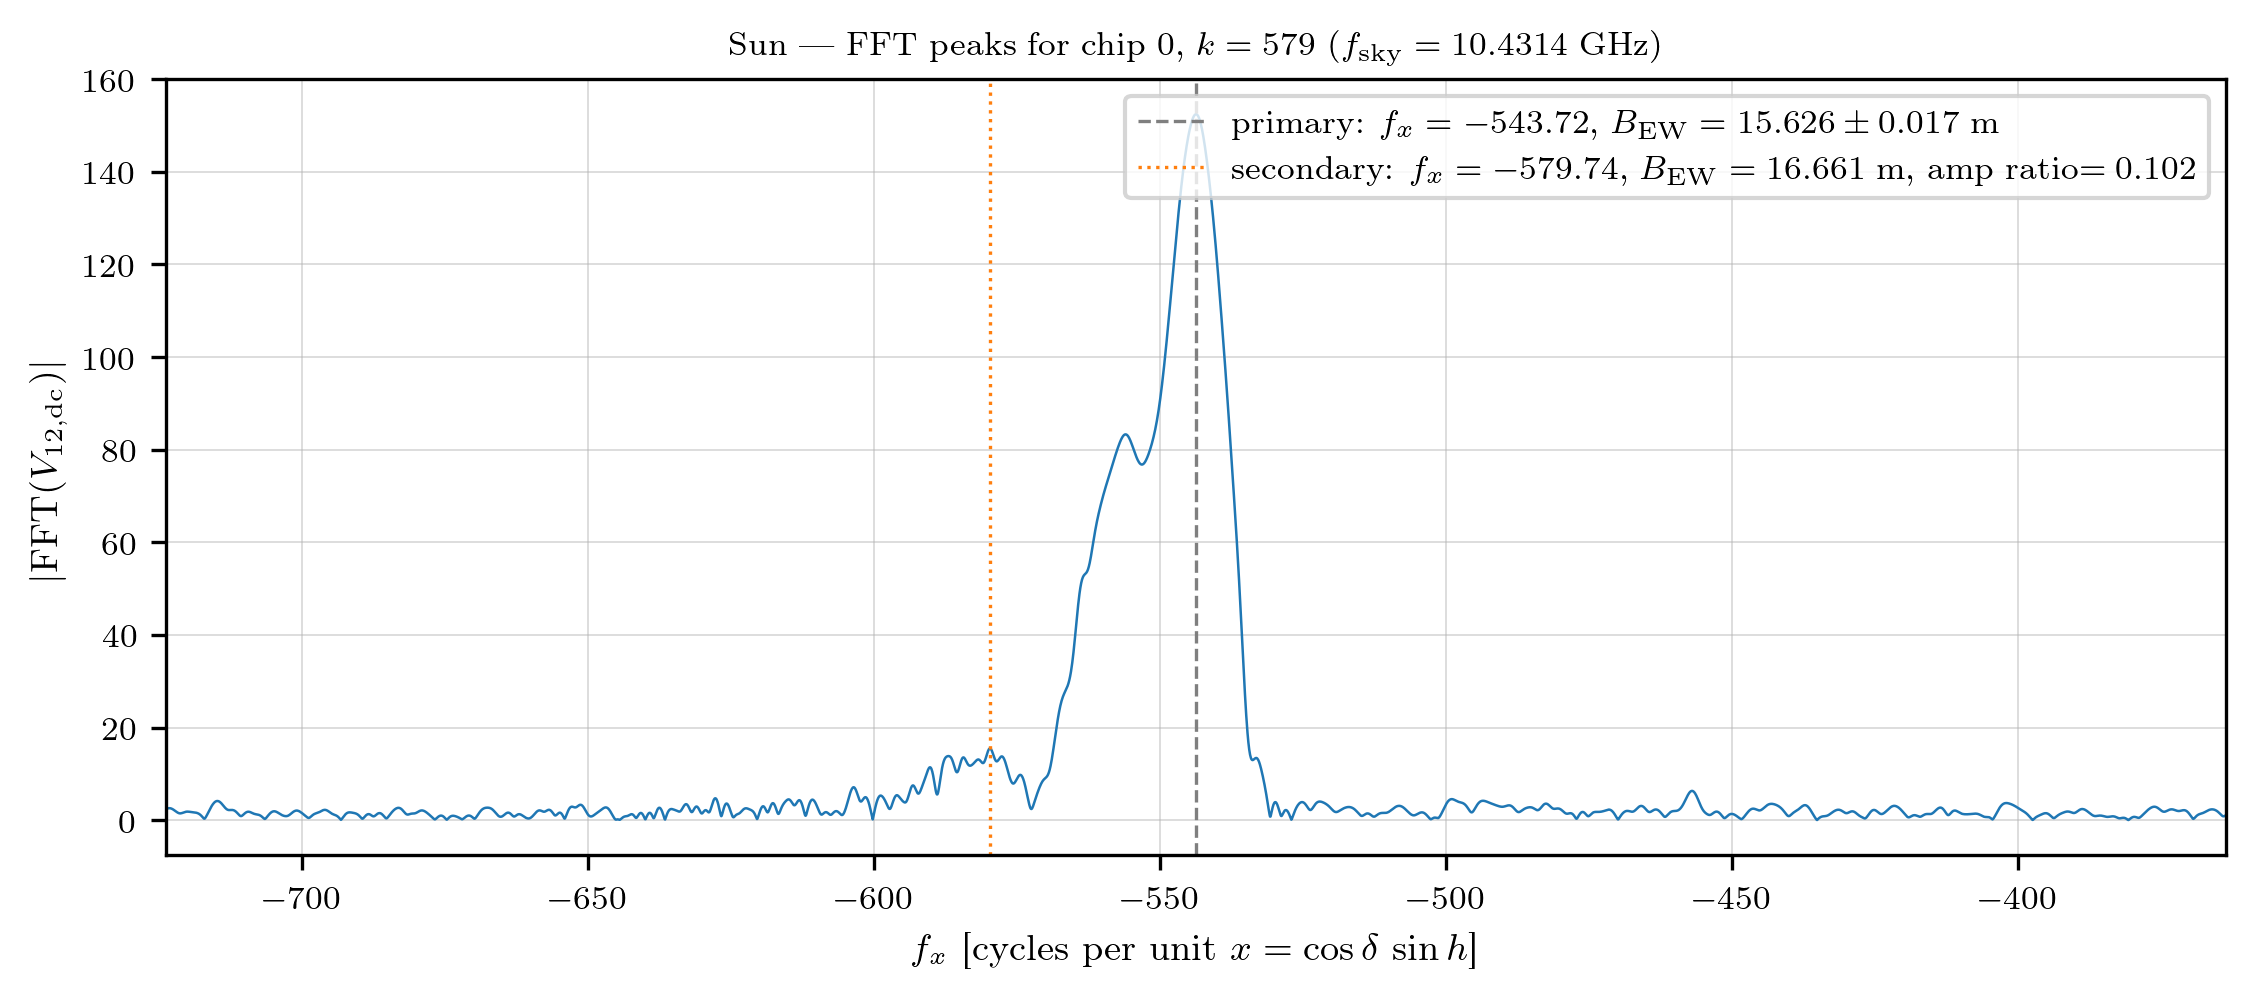

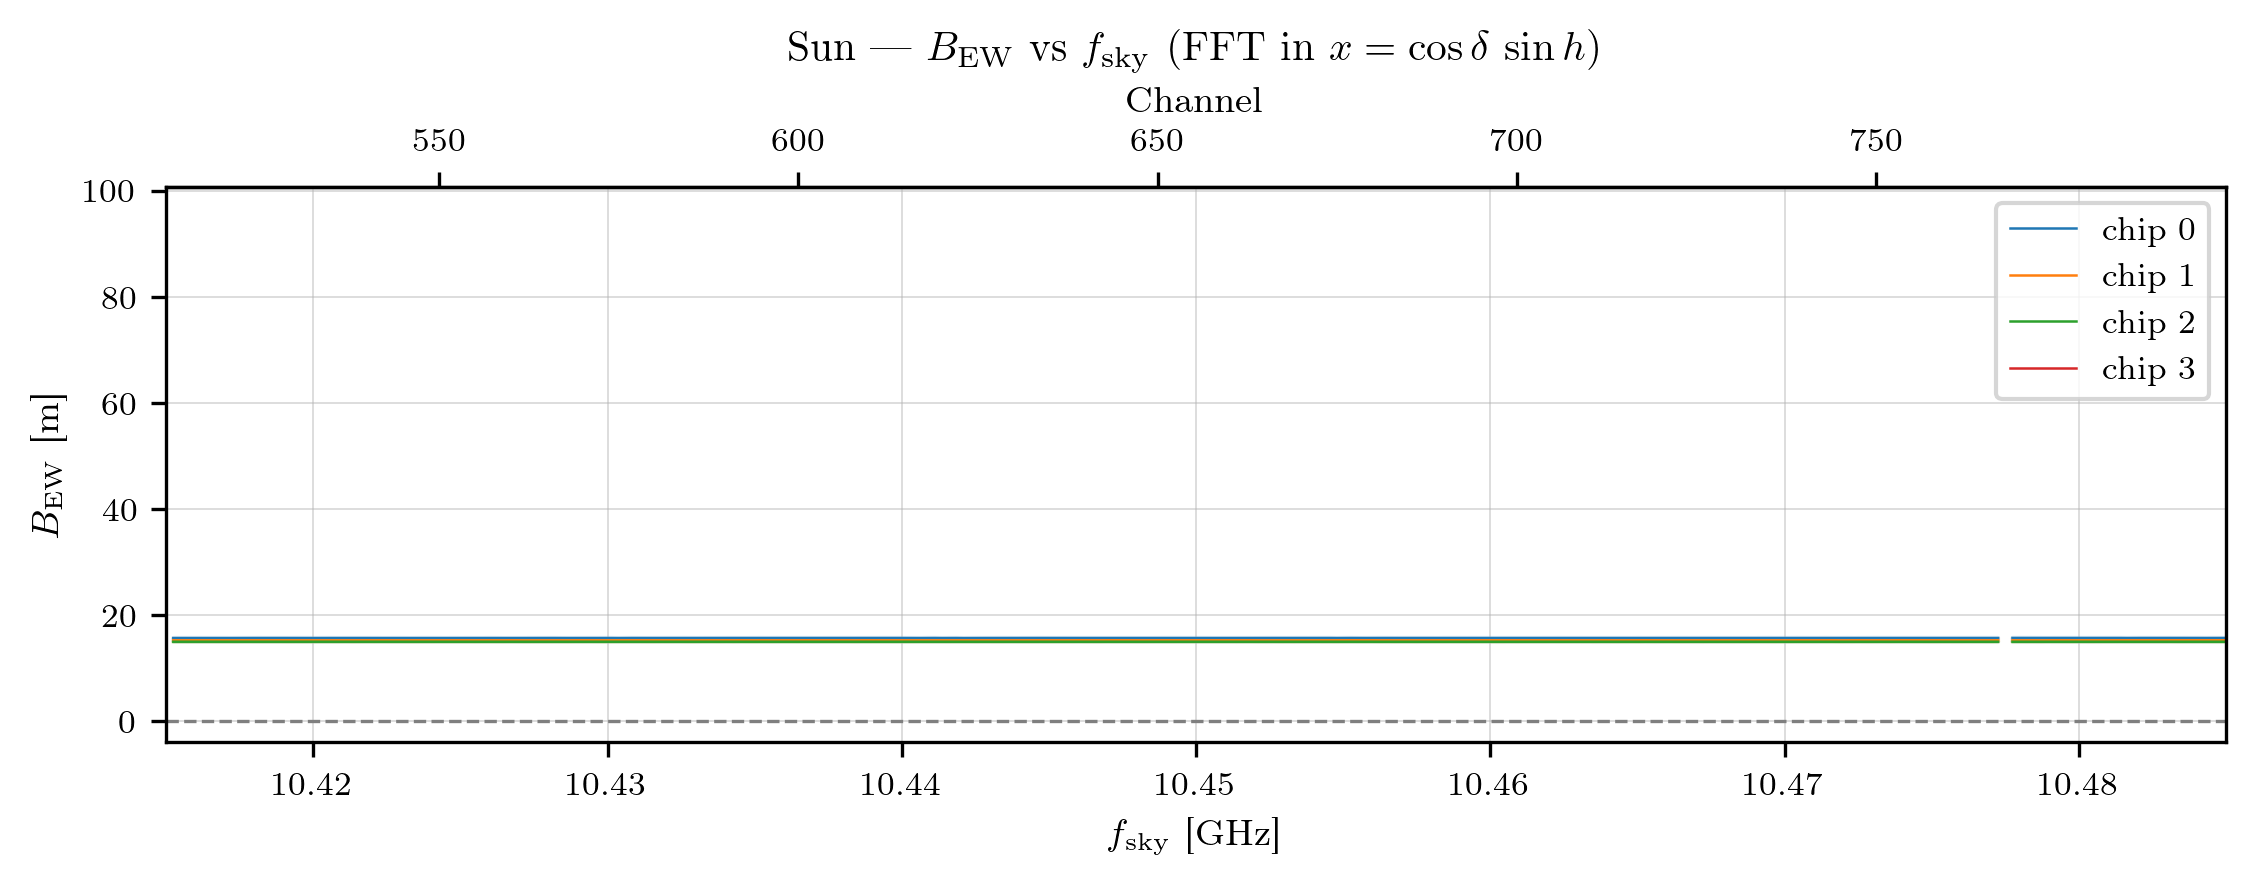

In [5]:
# ---------------------------------------------------------------------------
# FFT baseline estimator in x = cos(delta) * sin(h)
#
# A plain FFT in hour angle smears the fringe because phi(h) is proportional
# to sin(h), not to h itself. Remapping to
#
#   x = cos(delta) * sin(h)
#
# makes the point-source visibility approximately
#
#   V_k(x) ~ A_k exp[-i 2 pi (nu_k * B_EW / c) x + i phi_0],
#
# so the FFT peak in x-space directly yields B_EW.
# ---------------------------------------------------------------------------

_C = 299792458.0
FFT_PAD_FAC = 16
FFT_MIN_SAMPLES = 16
FFT_ZERO_EXCLUDE_CYCLES = 25.0
FFT_SPAN_ERR_FACTOR = 0.5
FFT_SECOND_PEAK_MIN_SEP_CYCLES = 15.0

band_mask = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
example_chip_idx = int(np.argmax(N_caps))


def _fft_peak_refined(freq_axis, amp, peak_idx):
    if peak_idx <= 0 or peak_idx >= amp.size - 1:
        return freq_axis[peak_idx]

    y0, y1, y2 = amp[peak_idx - 1], amp[peak_idx], amp[peak_idx + 1]
    denom = y0 - 2.0 * y1 + y2
    if not np.isfinite(denom) or denom == 0.0:
        return freq_axis[peak_idx]

    delta = 0.5 * (y0 - y2) / denom
    delta = float(np.clip(delta, -0.5, 0.5))
    return freq_axis[peak_idx] + delta * (freq_axis[1] - freq_axis[0])


def _fft_sorted_local_peak_indices(amp, search):
    local = np.zeros_like(search, dtype=bool)
    local[1:-1] = search[1:-1] & (amp[1:-1] >= amp[:-2]) & (amp[1:-1] >= amp[2:])
    idx = np.flatnonzero(local)
    if idx.size == 0:
        idx = np.flatnonzero(search)
    if idx.size == 0:
        return idx
    return idx[np.argsort(amp[idx])[::-1]]


baseline_fft_chips = []
baseline_fft_err_chips = []
baseline_fft_err_grid_chips = []
baseline_fft_err_span_chips = []
fft_snr_chips = []
fft_example = None

for c, (ha_c, dc_c, unix_c) in enumerate(zip(ha_chips, corr_dc_chips, unix_chips)):
    dec_deg_c = np.array([get_sun(Time(t, format='unix')).dec.deg for t in unix_c])
    x_c = np.cos(np.radians(dec_deg_c)) * np.sin(np.radians(ha_c))

    order = np.argsort(x_c)
    x_sort = x_c[order]
    dc_sort = dc_c[order, :]

    nx = x_sort.size
    if nx < FFT_MIN_SAMPLES:
        baseline_fft_chips.append(np.full(N_CH, np.nan))
        baseline_fft_err_chips.append(np.full(N_CH, np.nan))
        baseline_fft_err_grid_chips.append(np.full(N_CH, np.nan))
        baseline_fft_err_span_chips.append(np.full(N_CH, np.nan))
        fft_snr_chips.append(np.full(N_CH, np.nan))
        print(f'Chip {c}: skipped (only {nx} captures)')
        continue

    x_span = float(x_sort.max() - x_sort.min())
    fx_err_span = FFT_SPAN_ERR_FACTOR / x_span if x_span > 0 else np.nan
    x_uniform = np.linspace(x_sort.min(), x_sort.max(), nx)
    dx = float(np.median(np.diff(x_uniform)))
    n_pad = int(FFT_PAD_FAC * nx)
    fx_axis = np.fft.fftshift(np.fft.fftfreq(n_pad, d=dx))
    zero_mask = np.abs(fx_axis) < FFT_ZERO_EXCLUDE_CYCLES
    window = np.hanning(nx)

    baseline_fft = np.full(N_CH, np.nan)
    baseline_fft_err = np.full(N_CH, np.nan)
    baseline_fft_err_grid = np.full(N_CH, np.nan)
    baseline_fft_err_span = np.full(N_CH, np.nan)
    fft_snr = np.full(N_CH, np.nan)

    for k in range(N_CH):
        if k in BAD_CHANNELS:
            continue

        vis = dc_sort[:, k]
        valid = np.isfinite(x_sort) & np.isfinite(vis.real) & np.isfinite(vis.imag)
        if valid.sum() < FFT_MIN_SAMPLES:
            continue

        xv = x_sort[valid]
        vv = vis[valid]
        if np.unique(xv).size < FFT_MIN_SAMPLES:
            continue

        vis_uniform = (
            np.interp(x_uniform, xv, vv.real)
            + 1j * np.interp(x_uniform, xv, vv.imag)
        )
        vis_uniform = (vis_uniform - np.mean(vis_uniform)) * window

        spec = np.fft.fftshift(np.fft.fft(vis_uniform, n=n_pad))
        amp = np.abs(spec)
        search = (~zero_mask) & np.isfinite(amp)
        if not np.any(search):
            continue

        peak_candidates = _fft_sorted_local_peak_indices(amp, search)
        peak_idx = peak_candidates[0]
        fx_peak = _fft_peak_refined(fx_axis, amp, peak_idx)

        secondary_idx = None
        secondary_fx_peak = np.nan
        secondary_baseline = np.nan
        secondary_amp = np.nan
        for candidate_idx in peak_candidates[1:]:
            if abs(fx_axis[candidate_idx] - fx_axis[peak_idx]) >= FFT_SECOND_PEAK_MIN_SEP_CYCLES:
                secondary_idx = int(candidate_idx)
                secondary_fx_peak = _fft_peak_refined(fx_axis, amp, secondary_idx)
                secondary_baseline = abs(secondary_fx_peak) * _C / (F_SKY_GHZ[k] * 1e9)
                secondary_amp = amp[secondary_idx]
                break

        baseline_fft[k] = abs(fx_peak) * _C / (F_SKY_GHZ[k] * 1e9)
        baseline_fft_err_grid[k] = 0.5 * abs(fx_axis[1] - fx_axis[0]) * _C / (F_SKY_GHZ[k] * 1e9)
        baseline_fft_err_span[k] = fx_err_span * _C / (F_SKY_GHZ[k] * 1e9)
        baseline_fft_err[k] = max(baseline_fft_err_grid[k], baseline_fft_err_span[k])

        off_peak = search.copy()
        off_peak[max(0, peak_idx - 3):min(n_pad, peak_idx + 4)] = False
        noise_floor = np.median(amp[off_peak]) if np.any(off_peak) else np.nan
        fft_snr[k] = amp[peak_idx] / noise_floor if np.isfinite(noise_floor) and noise_floor > 0 else np.nan

        preferred_example = (c == example_chip_idx and k == k_peak)
        if fft_example is None or preferred_example:
            fft_example = {
                'chip_idx': c,
                'channel_idx': k,
                'f_sky_ghz': F_SKY_GHZ[k],
                'fx_axis': fx_axis.copy(),
                'amp': amp.copy(),
                'fx_peak': fx_peak,
                'peak_amp': amp[peak_idx],
                'baseline_m': baseline_fft[k],
                'baseline_err_m': baseline_fft_err[k],
                'baseline_err_grid_m': baseline_fft_err_grid[k],
                'baseline_err_span_m': baseline_fft_err_span[k],
                'secondary_fx_peak': secondary_fx_peak,
                'secondary_baseline_m': secondary_baseline,
                'secondary_amp': secondary_amp,
            }

    baseline_fft_chips.append(baseline_fft)
    baseline_fft_err_chips.append(baseline_fft_err)
    baseline_fft_err_grid_chips.append(baseline_fft_err_grid)
    baseline_fft_err_span_chips.append(baseline_fft_err_span)
    fft_snr_chips.append(fft_snr)

    band_valid = band_mask & np.isfinite(baseline_fft)
    if np.any(band_valid):
        b_med = np.nanmedian(baseline_fft[band_valid])
        b_p16, b_p84 = np.nanpercentile(baseline_fft[band_valid], [16, 84])
        b_scatter = 0.5 * (b_p84 - b_p16)
        e_med = np.nanmedian(baseline_fft_err[band_valid])
        snr_med = np.nanmedian(fft_snr[band_valid])
        print(
            f'Chip {c}:  HA {ha_c.min():.2f}° → {ha_c.max():.2f}°  |  '
            f'x {x_sort.min():.4f} → {x_sort.max():.4f}  |  '
            f'B_EW(FFT) = {b_med:.3f} ± {e_med:.3f} m  '
            f'(channel scatter p16={b_p16:.3f}, p84={b_p84:.3f}, half-width~{b_scatter:.3f} m)  |  '
            f'FFT SNR med={snr_med:.1f}'
        )
    else:
        print(f'Chip {c}: no finite FFT baseline estimates in band')

if fft_example is not None:
    print(
        f"Representative FFT peaks for chip {fft_example['chip_idx']}, k={fft_example['channel_idx']} "
        f"at f_sky={fft_example['f_sky_ghz']:.4f} GHz: primary f_x={fft_example['fx_peak']:.2f} "
        f"(B_EW={fft_example['baseline_m']:.3f} ± {fft_example['baseline_err_m']:.3f} m)"
    )
    if np.isfinite(fft_example['secondary_fx_peak']):
        print(
            f"Secondary separated peak: f_x={fft_example['secondary_fx_peak']:.2f} "
            f"(B_EW={fft_example['secondary_baseline_m']:.3f} m, "
            f"amp ratio={fft_example['secondary_amp'] / fft_example['peak_amp']:.3f})"
        )
    fig, ax = plot_fft_peak_diagnostic(
        fx_axis=fft_example['fx_axis'],
        fft_amp=fft_example['amp'],
        fx_peak=fft_example['fx_peak'],
        baseline_m=fft_example['baseline_m'],
        baseline_err_m=fft_example['baseline_err_m'],
        chip_idx=fft_example['chip_idx'],
        channel_index=fft_example['channel_idx'],
        channel_freq_ghz=fft_example['f_sky_ghz'],
        secondary_fx_peak=fft_example['secondary_fx_peak'],
        secondary_baseline_m=fft_example['secondary_baseline_m'],
        secondary_amp=fft_example['secondary_amp'],
        primary_amp=fft_example['peak_amp'],
    )
    plt.show()

fig, ax = plot_baseline_vs_frequency(
    f_sky_ghz=F_SKY_GHZ,
    baseline_chips=baseline_fft_chips,
    baseline_err_chips=baseline_fft_err_chips,
    plot_band_ghz=PLOT_BAND_GHZ,
    f_rf0_hz=F_RF0_HZ,
    df_hz=DF_HZ,
)
ax.set_title(r'Sun --- $B_{\rm EW}$ vs $f_{\rm sky}$ (FFT in $x=\cos\delta\,\sin h$)')
plt.show()